In [1]:
import tensorflow as tf
print("GPU Available:", len(tf.config.list_physical_devices('GPU')))

GPU Available: 1


In [2]:
!pip install scapy pandas numpy matplotlib seaborn scikit-learn tensorflow keras-tuner

In [6]:
import os
import glob
import pandas as pd
import numpy as np
from scapy.all import rdpcap, IP, TCP, UDP
from scipy.stats import entropy
from collections import defaultdict

# CONFIGURATION
PCAP_PATH = r"H:\project\Ddos attck preiction model\PCAP-01-12_0750-0818"
OUTPUT_FILE = "chronos_processed_data.csv"
PACKET_LIMIT = 5000 

def calculate_shannon_entropy(data):
    if len(data) <= 1: return 0
    counts, _ = np.histogram(data, bins=10, density=True)
    return entropy(counts + 1e-10)

def extract_features_from_pcap():
    # MODIFIED LINE: Look for files starting with "SAT" instead of "*.pcap"
    files = glob.glob(os.path.join(PCAP_PATH, "SAT*"))
    
    if not files:
        print(f"Error: Still no files found in {PCAP_PATH}")
        print("Please check if the folder path is exactly correct.")
        return

    print(f"Found {len(files)} files! Starting extraction...")
    
    dataset = []
    
    for i, pcap_file in enumerate(files):
        try:
            # Read packets
            packets = rdpcap(pcap_file, count=PACKET_LIMIT)
            flows = defaultdict(list)
            
            for pkt in packets:
                if IP in pkt:
                    key = f"{pkt[IP].src}-{pkt[IP].dst}-{pkt[IP].proto}"
                    flows[key].append(pkt.time)
            
            for flow_id, timestamps in flows.items():
                if len(timestamps) < 5: continue 
                
                ts = np.array(timestamps).astype(float)
                iat = np.diff(ts)
                
                avg_iat = np.mean(iat)
                ent = calculate_shannon_entropy(iat)
                var_iat = np.var(iat)
                pkt_count = len(timestamps)
                
                # Auto-Labeling
                if avg_iat < 0.05 and ent < 1.2:
                    label = 1 # Attack
                else:
                    label = 0 # Benign
                
                dataset.append([avg_iat, ent, var_iat, pkt_count, label])
                
            if (i + 1) % 5 == 0:
                print(f"Processed {i + 1}/{len(files)} files...")
                
        except Exception as e:
            print(f"Could not read {os.path.basename(pcap_file)}. It might not be a valid packet capture.")
            print(f"Error details: {e}")

    # Export
    if len(dataset) > 0:
        df = pd.DataFrame(dataset, columns=["Avg_IAT", "Entropy", "Variance", "Packet_Count", "Label"])
        df.to_csv(OUTPUT_FILE, index=False)
        print(f"\nSUCCESS! Extracted {len(df)} samples to {OUTPUT_FILE}")
    else:
        print("\nFailed to extract any valid data. The files might be corrupted or empty.")

# Execute extraction
extract_features_from_pcap()

Found 69 files! Starting extraction...
Processed 5/69 files...
Processed 10/69 files...
Processed 15/69 files...
Processed 20/69 files...
Processed 25/69 files...
Processed 30/69 files...
Processed 35/69 files...
Processed 40/69 files...
Processed 45/69 files...
Processed 50/69 files...
Processed 55/69 files...
Processed 60/69 files...
Processed 65/69 files...

SUCCESS! Extracted 207 samples to chronos_processed_data.csv


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the data you just created
print("Loading dataset...")
df = pd.read_csv("chronos_processed_data.csv")

# 2. Separate Inputs (X) and Output (y)
X = df.drop("Label", axis=1)
y = df["Label"]

# This makes sure 'Speed' and 'Entropy' are on the same math scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split: 80% for Training, 20% for the Final Exam (Testing)
# We use 'stratify=y' to make sure we have both Attacks and Humans in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Ready!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Loading dataset...
Data Ready!
Training samples: 165
Testing samples: 42


In [13]:
import keras_tuner as kt  
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

def build_model(hp):
    model = keras.Sequential()
    
    # Input: Matches your 4 features
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Tuner: Try 1 to 3 hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001) 
        ))
        model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='chronos_pcap_tuning',
    project_name='ddos_guard'
)

stop_early = callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("Tuning model on PCAP data...")
tuner.search(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[stop_early])
print("Tuning Complete.")

Reloading Tuner from chronos_pcap_tuning\ddos_guard\tuner0.json
Tuning model on PCAP data...
Tuning Complete.


AGGRESSIVE MODE: Training on 186 samples | Testing on 21 samples

STARTING TRAINING...
Epoch 1/150
1/5 [=====>........................] - ETA: 2s - loss: 0.7093 - accuracy: 0.4062
Epoch 1: val_accuracy improved from -inf to 0.89286, saving model to chronos_model.keras
5/5 [==============================] - 1s 53ms/step - loss: 0.6842 - accuracy: 0.5316 - val_loss: 0.6284 - val_accuracy: 0.8929
Epoch 2/150
1/5 [=====>........................] - ETA: 0s - loss: 0.6447 - accuracy: 0.6250
Epoch 2: val_accuracy improved from 0.89286 to 0.92857, saving model to chronos_model.keras
5/5 [==============================] - 0s 22ms/step - loss: 0.6029 - accuracy: 0.7785 - val_loss: 0.5478 - val_accuracy: 0.9286
Epoch 3/150
1/5 [=====>........................] - ETA: 0s - loss: 0.5652 - accuracy: 0.8438
Epoch 3: val_accuracy did not improve from 0.92857
5/5 [==============================] - 0s 14ms/step - loss: 0.5381 - accuracy: 0.8354 - val_loss: 0.4747 - val_accuracy: 0.9286
Epoch 4/150
1/5 [=

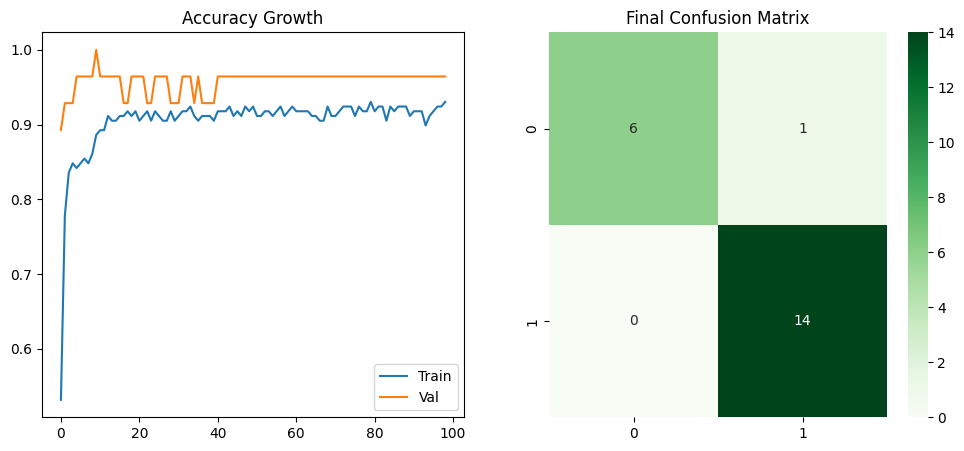

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.10, random_state=42, stratify=y
)

print(f"AGGRESSIVE MODE: Training on {len(X_train)} samples | Testing on {len(X_test)} samples")


model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    
    # Layer 1: High capacity to learn complex patterns
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Light dropout only
    
    # Layer 2: Refinement
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    
    # Layer 3: Final Decision
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


checkpoint = callbacks.ModelCheckpoint(
    "chronos_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1
)

# Patience increased to 20 to prevent early quitting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("\nSTARTING TRAINING...")
history = model.fit(
    X_train, y_train,
    epochs=150, 
    validation_split=0.15, 
    callbacks=[checkpoint, early_stop],
    verbose=1
)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFINAL SCORE: {accuracy * 100:.2f}%")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy Growth')
plt.legend()

plt.subplot(1, 2, 2)
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Final Confusion Matrix')
plt.show()

In [27]:
# Save the final model manually
model.save("chronos_model.keras")

print("SUCCESS: Model saved as 'startbustersdossattck_model.keras'")

SUCCESS: Model saved as 'startbustersdossattck_model.keras'
